# GWAS pipeline 1 — From genotypes to loci

**A quality-controlled genome-wide association study**

This is the first of a two-notebook chapter that walks through a complete,
best-practice **genome-wide association study (GWAS)** with
`omicverse.genetics`. Rather than listing methods, the two notebooks tell
**one scientific story**: every step feeds the next, and at every step we
check that the analysis recovers a *known planted truth*.

## The scientific question

We have genotyped a cohort of 2,000 individuals at 6,000 SNPs and measured
a **quantitative trait** on each of them. We want to answer:

> *Which genetic loci influence this trait, and — eventually — through
> which gene and in which cell type do they act?*

This notebook covers the **statistical-genetics half**: take raw genotypes,
quality-control them, account for population structure, run a calibrated
association scan, and resolve each association down to a credible set of
candidate causal variants. The companion notebook
(`t_genetics_02_functional_followup`) then turns those loci into a
biological mechanism.

## The study design

We use a *simulated* cohort so that the ground truth is known and every
step can be checked. The simulation lives in the package itself
(`ov.genetics.simulate_gwas_study`) — inline simulation code does not
belong in a tutorial. The cohort is internally consistent:

- **genotypes** with realistic linkage-disequilibrium (LD) block structure
  and two subpopulations with slightly divergent allele frequencies;
- a **heritable quantitative trait** ($h^2 = 0.4$) driven by 5 causal SNPs,
  *plus a population-structure effect* — so a naive scan will be inflated
  and we will *need* to correct for structure;
- the planted **causal SNPs** are returned explicitly, so we can confirm
  the pipeline recovers them.

## The pipeline

```
 raw genotypes + trait
        |
   [1] Sample QC      call rate, heterozygosity, relatedness, sex
        |
   [2] Variant QC     MAF, Hardy-Weinberg equilibrium, call rate
        |
   [3] Population      genotype PCA -> covariates
       structure
        |
   [4] Association     naive  vs  PC-adjusted scan
        |
   [5] Diagnostics     lambda_GC, Q-Q plot, Manhattan plot
        |
   [6] Define loci     genome-wide threshold, LD clumping
        |
   [7] Fine-mapping    SuSiE -> 95% credible set
        |
   QC'd loci + credible sets  ->  notebook 2
```

Each step below opens with the *why* — the rationale and the standard
thresholds — before the code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

import omicverse as ov

ov.plot_set()
np.random.seed(0)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Step 0 — Load the cohort

`ov.genetics.simulate_gwas_study` returns a `GWASStudy` object bundling
four pieces of one coherent study. In this notebook we only use the
**genotype** (an `AnnData` of samples x SNPs) and the **phenotype**; the
expression and single-cell data are used in notebook 2.

A real study would instead start from `ov.genetics.read_plink('cohort')`
(a PLINK `.bed/.bim/.fam` fileset) or `ov.genetics.read_vcf(...)` — the
returned `AnnData` has the same shape, so the rest of the pipeline is
identical.

In [2]:
study = ov.genetics.simulate_gwas_study(
    n_samples=2000, n_snps=6000, n_blocks=30,
    n_causal=5, h2=0.4, seed=0,
)
study

GWASStudy(
  genotype  : 2000 samples x 6000 SNPs
  phenotype : quantitative trait, h2 = 0.4
  expression: 2000 samples x 200 genes
  scrna     : 1500 cells x 200 genes
  truth     : causal_snps=['rs002257', 'rs003151', 'rs004318', 'rs004824', 'rs005088'], causal_gene='GENE0000', cell_type='Monocyte'
)

The genotype `AnnData` follows the omicverse convention — **rows are
samples, columns are SNPs**. `.X` holds 0/1/2 allele dosages; `.var`
carries the SNP annotation (chromosome, position, MAF, LD block); `.obs`
carries the per-sample phenotype and a subpopulation label.

In [3]:
geno = study.genotype
pheno = study.phenotype

print(f"genotype : {geno.n_obs} samples x {geno.n_vars} SNPs")
print(f"dosage values present: {np.unique(geno.X)}")
geno.var.head()

genotype : 2000 samples x 6000 SNPs


dosage values present: [0. 1. 2.]


,chrom,pos,maf,block,causal
rs000000,1,1000000,0.33800,0,False
rs000001,1,1005000,0.25725,0,False
rs000002,1,1010000,0.08975,0,False
rs000003,1,1015000,0.08800,0,False
rs000004,1,1020000,0.47525,0,False


In [4]:
# Sample metadata: the trait and the (latent) subpopulation label.
geno.obs.head()

,population,phenotype
IND00000,pop0,1.592222
IND00001,pop1,-0.457588
IND00002,pop1,0.282443
IND00003,pop1,-1.670404
IND00004,pop1,0.871445


The trait is continuous, so we will run a **linear** association model.
We can already see the planted ground truth — but in a real study this is
exactly what we are trying to discover. We keep it aside to *grade* the
pipeline at each step.

In [5]:
truth = study.truth
print("Planted causal SNPs :", truth["causal_snps"])
print("Lead causal SNP     :", truth["lead_causal_snp"], "(the mediated locus)")
print("Causal gene         :", truth["causal_gene"])
print("Simulated h2        :", study.params["h2"])

Planted causal SNPs : ['rs002257', 'rs003151', 'rs004318', 'rs004824', 'rs005088']
Lead causal SNP     : rs002257 (the mediated locus)
Causal gene         : GENE0000
Simulated h2        : 0.4


## Step 1 — Sample (individual) quality control

Before any association test we remove **low-quality samples**. A bad
sample contributes noise to every SNP at once, so this comes first.
The standard per-individual checks are:

| Check | What it catches | Typical threshold |
|---|---|---|
| **Call rate** | poorly-genotyped DNA samples | drop if missingness > 2–5% (call rate < 0.95–0.98) |
| **Heterozygosity** | DNA contamination (excess het) or inbreeding (deficit) | drop if outside mean ± 3 SD |
| **Relatedness** | duplicates / cryptic relatives that violate the independence assumption | drop one of each pair with kinship > 0.0884 (≈ 2nd-degree) |
| **Sex check** | sample swaps / mislabelling | drop if genetic sex (X-chr het / Y-chr calls) ≠ recorded sex |

`ov.genetics.gwas_qc` applies the **call-rate** filter directly (it is the
one universal numeric filter); heterozygosity, relatedness and sex-check
need extra data (a relatedness matrix, X/Y SNPs) and are usually run in
PLINK / KING upstream. Below we compute the per-sample call rate and the
per-sample mean heterozygosity so we can *see* the QC decision.

In [6]:
# Per-sample call rate and heterozygosity from the dosage matrix.
X = geno.X.astype(float)
sample_call_rate = 1.0 - np.isnan(X).mean(axis=1)
sample_het = np.mean(X == 1, axis=1)        # fraction of heterozygous calls

qc_obs = pd.DataFrame({
    "call_rate": sample_call_rate,
    "heterozygosity": sample_het,
}, index=geno.obs_names)
qc_obs.describe().round(4)

,call_rate,heterozygosity
count,2000.0,2000.0000
mean,1.0,0.3597
std,0.0,0.0110
min,1.0,0.3252
25%,1.0,0.3522
50%,1.0,0.3597
75%,1.0,0.3672
max,1.0,0.3973


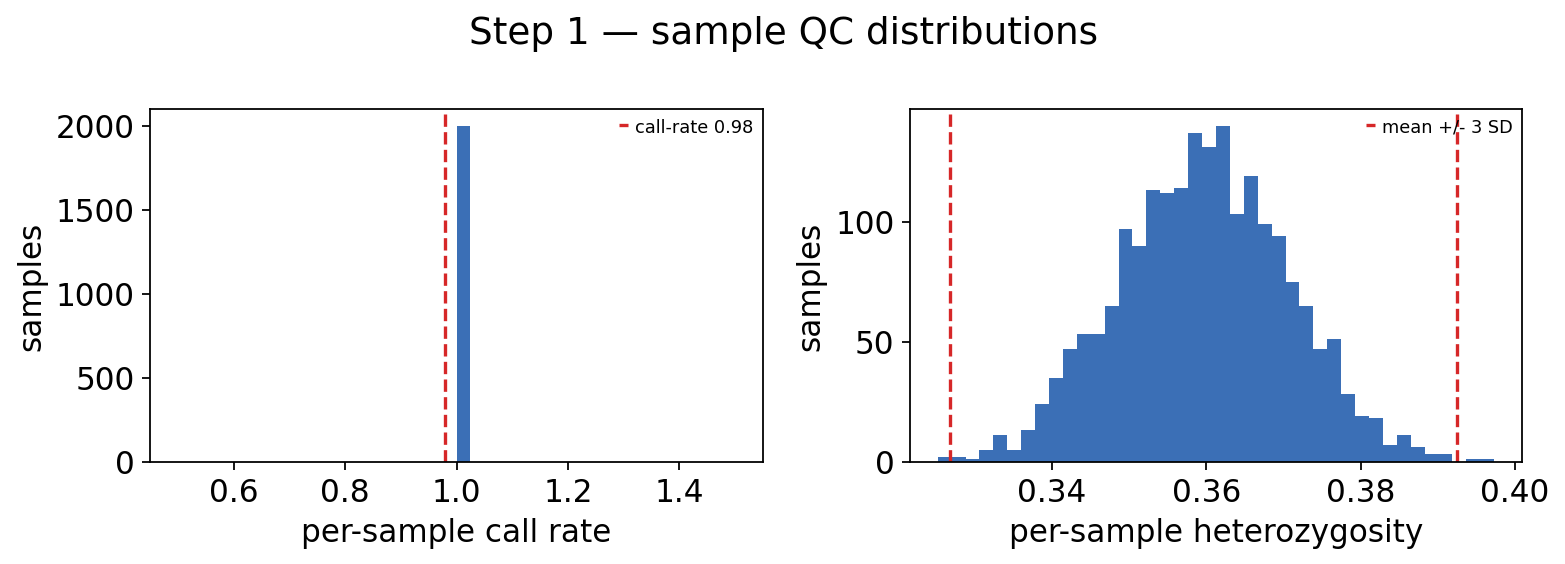

In [7]:
# Heterozygosity outlier bounds: mean +/- 3 SD (a contamination flag).
het_mean, het_sd = qc_obs["heterozygosity"].mean(), qc_obs["heterozygosity"].std()
het_lo, het_hi = het_mean - 3 * het_sd, het_mean + 3 * het_sd

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(qc_obs["call_rate"], bins=40, color="#3b6fb6")
axes[0].axvline(0.98, color="#d62728", ls="--", label="call-rate 0.98")
axes[0].set(xlabel="per-sample call rate", ylabel="samples")
axes[1].hist(qc_obs["heterozygosity"], bins=40, color="#3b6fb6")
axes[1].axvline(het_lo, color="#d62728", ls="--")
axes[1].axvline(het_hi, color="#d62728", ls="--", label="mean +/- 3 SD")
axes[1].set(xlabel="per-sample heterozygosity", ylabel="samples")
for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle("Step 1 — sample QC distributions")
plt.tight_layout(); plt.show()

In [8]:
n_low_call = int((qc_obs["call_rate"] < 0.98).sum())
n_het_out = int(((qc_obs["heterozygosity"] < het_lo) |
                 (qc_obs["heterozygosity"] > het_hi)).sum())
print(f"samples with call rate < 0.98          : {n_low_call}")
print(f"samples outside +/- 3 SD heterozygosity : {n_het_out}")
print("Clean simulated cohort; real data typically loses 1-3% of samples.")

samples with call rate < 0.98          : 0
samples outside +/- 3 SD heterozygosity : 4
Clean simulated cohort; real data typically loses 1-3% of samples.


## Step 2 — Variant (SNP) quality control

Now we remove **unreliable SNPs**. A poorly-behaved variant produces
spurious associations, so it must go *before* the scan. The three
standard per-SNP filters are:

| Check | What it catches | Typical threshold |
|---|---|---|
| **Minor-allele frequency (MAF)** | very rare variants have almost no power and unstable estimates | drop if MAF < 0.01 (common-variant GWAS) |
| **Hardy-Weinberg equilibrium (HWE)** | genotyping error (a deviation from expected genotype proportions in controls) | drop if HWE exact-test $p < 10^{-6}$ |
| **Call rate** | badly-clustering probes | drop if SNP missingness > 2–5% |

`ov.genetics.gwas_qc` applies all three in one call. It runs the
**Wigginton–Cutler–Abecasis exact HWE test** (the correct test for finite
samples, not a chi-square approximation) and writes the per-SNP metrics
back into `.var` so we can inspect *why* each SNP was kept or dropped.

In [9]:
geno_qc = ov.genetics.gwas_qc(
    geno,
    call_rate=0.98,        # SNP call rate >= 98%
    maf=0.01,              # minor-allele frequency >= 1%
    hwe=1e-6,              # HWE exact-test p >= 1e-6
    sample_call_rate=0.98, # sample call rate >= 98%
)
geno_qc.uns["gwas_qc"]

{'n_snps_in': 6000,
 'n_snps_kept': 5993,
 'n_samples_in': 2000,
 'n_samples_kept': 2000,
 'thresholds': {'call_rate': 0.98,
  'maf': 0.01,
  'hwe': 1e-06,
  'sample_call_rate': 0.98}}

`gwas_qc` reports how many SNPs and samples survived. The simulated
genotypes are high-quality, so only a handful of SNPs drift below the MAF
or HWE thresholds — exactly the variants that carry the least information.
The QC'd `AnnData` keeps the per-SNP metrics in `.var` so we can see *why*
each surviving SNP passed.

In [10]:
# gwas_qc records call_rate, maf and the HWE exact-test p on .var.
metrics = geno_qc.var[["maf", "hwe_p", "call_rate"]]
print(f"variants in  : {geno.n_vars}")
print(f"variants kept: {geno_qc.n_vars}")
print(f"variants dropped by MAF / HWE / call-rate: "
      f"{geno.n_vars - geno_qc.n_vars}")
metrics.describe().round(4)

variants in  : 6000
variants kept: 5993
variants dropped by MAF / HWE / call-rate: 7


,maf,hwe_p,call_rate
count,5993.0000,5993.0000,5993.0
mean,0.2742,0.4666,1.0
std,0.1324,0.3147,0.0
min,0.0142,0.0000,1.0
25%,0.1625,0.1841,1.0
50%,0.2765,0.4492,1.0
75%,0.3882,0.7411,1.0
max,0.5000,1.0000,1.0


In [11]:
# A QC'd cohort still contains all the planted causal SNPs — good, the
# filters removed noise, not signal.
kept_causal = [s for s in truth["causal_snps"] if s in geno_qc.var_names]
print(f"causal SNPs surviving QC: {len(kept_causal)} / {len(truth['causal_snps'])}")
print(kept_causal)

causal SNPs surviving QC: 5 / 5
['rs002257', 'rs003151', 'rs004318', 'rs004824', 'rs005088']


## Step 3 — Population structure

People with different ancestry differ *both* in allele frequencies *and*
in many traits, for reasons that have nothing to do with the variant under
test. If we ignore this, ancestry becomes a **confounder** and the whole
scan is inflated with false positives — this is **population
stratification**.

The standard fix is **principal-component analysis (PCA) of the genotype
matrix**: the top PCs capture the main axes of ancestry, and we include
them as **covariates** in every association test. To choose how many PCs
to carry, look at the scree plot (the variance explained) and keep the PCs
*before* the elbow — in practice the first 5–10 (10–20 for very diverse
cohorts). Here our cohort has two subpopulations, so we expect **PC1** to
separate them.

In [12]:
# PCA on the QC'd genotypes (scaled, as is standard for genotype PCA).
geno_pca = geno_qc.copy()
sc.pp.scale(geno_pca, max_value=10)
sc.tl.pca(geno_pca, n_comps=10)
pcs_all = geno_pca.obsm["X_pca"]
var_ratio = geno_pca.uns["pca"]["variance_ratio"]
print("variance explained by PC1-PC10:")
print(np.round(var_ratio, 4))

variance explained by PC1-PC10:
[0.0211 0.0024 0.0024 0.0023 0.0023 0.0023 0.0023 0.0022 0.0022 0.0022]


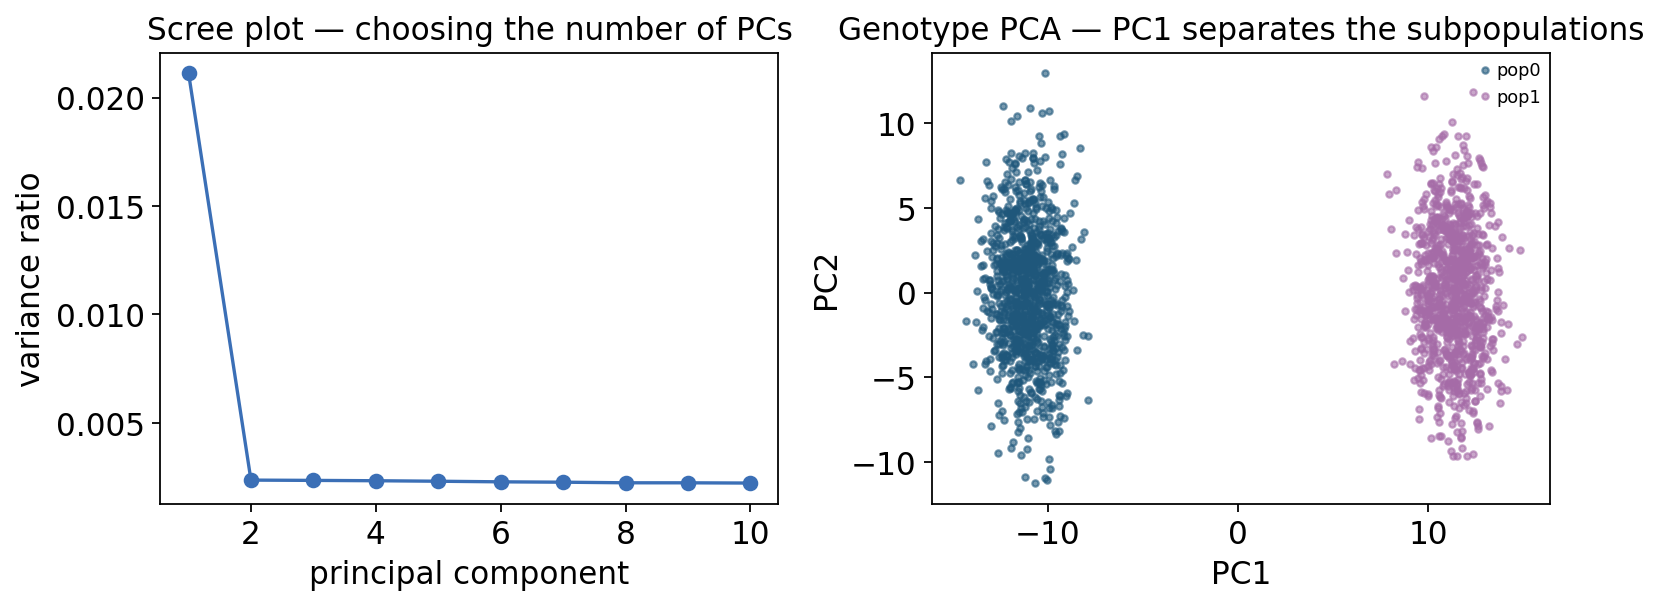

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Scree plot: where does the variance-explained curve flatten?
axes[0].plot(np.arange(1, 11), var_ratio, "o-", color="#3b6fb6")
axes[0].set_xlabel("principal component"); axes[0].set_ylabel("variance ratio")
axes[0].set_title("Scree plot — choosing the number of PCs")

# PC1 vs PC2, coloured by the (latent) subpopulation label.
pop = geno_qc.obs["population"].astype(str).values
for p in sorted(np.unique(pop)):
    m = pop == p
    axes[1].scatter(pcs_all[m, 0], pcs_all[m, 1], s=8, label=p, alpha=0.6)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Genotype PCA — PC1 separates the subpopulations")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The scree plot flattens after the first couple of components, and the
PC1–PC2 scatter shows the two subpopulations cleanly separated along
**PC1** — confirming the structure is real. We carry the **first 5 PCs**
as covariates: enough to absorb the structure with margin, few enough to
keep degrees of freedom.

In [14]:
n_pcs = 5
covariates = pcs_all[:, :n_pcs]
print(f"using {n_pcs} genotype PCs as association covariates; "
      f"covariate matrix shape = {covariates.shape}")

using 5 genotype PCs as association covariates; covariate matrix shape = (2000, 5)


## Step 4 — Association testing: naive vs PC-adjusted

Now the scan itself. `ov.genetics.gwas_association` regresses the trait on
each SNP's dosage. For a quantitative trait we use `model='linear'`
(ordinary least squares); for a binary case/control trait we would use
`model='logistic'`.

To *show* why population-structure correction matters, we run the scan
**twice**:

1. **naive** — no covariates;
2. **PC-adjusted** — the 5 genotype PCs as covariates.

If structure is confounding the trait, the naive scan will be inflated and
the PC-adjusted scan will be calibrated. We compare them in step 5.

In [15]:
geno_df = pd.DataFrame(
    geno_qc.X, index=geno_qc.obs_names, columns=geno_qc.var_names,
)
pheno_qc = pheno.loc[geno_qc.obs_names]

# Naive scan: trait ~ SNP, no covariates.
res_naive = ov.genetics.gwas_association(geno_df, pheno_qc, model="linear")

# PC-adjusted scan: trait ~ SNP + PC1..PC5.
res_adj = ov.genetics.gwas_association(
    geno_df, pheno_qc, covariates=covariates, model="linear",
)
res_adj.head()

,snp,beta,se,stat,pvalue,n
0,rs003151,0.587293,0.047080,12.474414,1.919663e-34,2000
1,rs004318,-0.543695,0.048417,-11.229531,2.042163e-28,2000
2,rs004824,0.507054,0.048152,10.530279,2.848487e-25,2000
3,rs002257,0.469036,0.048064,9.758618,5.223671e-22,2000
4,rs005088,0.430764,0.050492,8.531285,2.818686e-17,2000


Each scan returns a tidy per-SNP table (effect size `beta`, standard
error `se`, test statistic, `pvalue`), sorted by p-value. We attach the
SNP annotation (chromosome, position) so we can draw a Manhattan plot and
define loci later.

In [16]:
annot = geno_qc.var[["chrom", "pos", "block", "causal"]]
res_naive = res_naive.merge(annot, left_on="snp", right_index=True)
res_adj = res_adj.merge(annot, left_on="snp", right_index=True)
res_adj.sort_values("pvalue").head(8)

,snp,beta,se,stat,pvalue,n,chrom,pos,block,causal
0,rs003151,0.587293,0.047080,12.474414,1.919663e-34,2000,16,1755000,15,True
1,rs004318,-0.543695,0.048417,-11.229531,2.042163e-28,2000,22,1590000,21,True
2,rs004824,0.507054,0.048152,10.530279,2.848487e-25,2000,22,1120000,24,True
3,rs002257,0.469036,0.048064,9.758618,5.223671e-22,2000,12,1285000,11,True
4,rs005088,0.430764,0.050492,8.531285,2.818686e-17,2000,22,1440000,25,True
5,rs004823,0.408245,0.049594,8.231689,3.296328e-16,2000,22,1115000,24,False
6,rs004317,-0.391660,0.051850,-7.553734,6.403568e-14,2000,22,1585000,21,False
7,rs004825,0.356308,0.051484,6.920789,6.032549e-12,2000,22,1125000,24,False


## Step 5 — Diagnostics: is the scan calibrated?

Before we trust a single hit we must check the scan is **well-calibrated**
— that the bulk of p-values follows the null. Two standard diagnostics:

- **Genomic-inflation factor $\lambda_{GC}$** — the ratio of the median
  observed association $\chi^2$ to its null expectation. $\lambda_{GC}
  \approx 1$ means calibrated; $\lambda_{GC} \gg 1$ flags stratification
  or cryptic relatedness. (Very large studies tolerate a slightly raised
  $\lambda_{GC}$ from true polygenicity — the per-SNP $\lambda_{GC,1000}$
  rescaling exists for that — but a small study like this one should sit
  near 1.)
- **Q-Q plot** — observed vs expected $-\log_{10}(p)$. A calibrated scan
  hugs the diagonal and lifts off it only in the extreme tail (true
  signal). A scan that departs the diagonal *everywhere* is inflated.

In [17]:
lambda_naive = ov.genetics.genomic_inflation(res_naive["pvalue"])
lambda_adj = ov.genetics.genomic_inflation(res_adj["pvalue"])
print(f"lambda_GC, naive scan       : {lambda_naive:.3f}")
print(f"lambda_GC, PC-adjusted scan : {lambda_adj:.3f}")
print()
if lambda_naive > 1.1:
    print("-> the naive scan is INFLATED: ancestry is confounding the trait.")
if abs(lambda_adj - 1.0) < 0.1:
    print("-> the PC-adjusted scan is well-calibrated.")

lambda_GC, naive scan       : 1.499
lambda_GC, PC-adjusted scan : 0.998

-> the naive scan is INFLATED: ancestry is confounding the trait.
-> the PC-adjusted scan is well-calibrated.


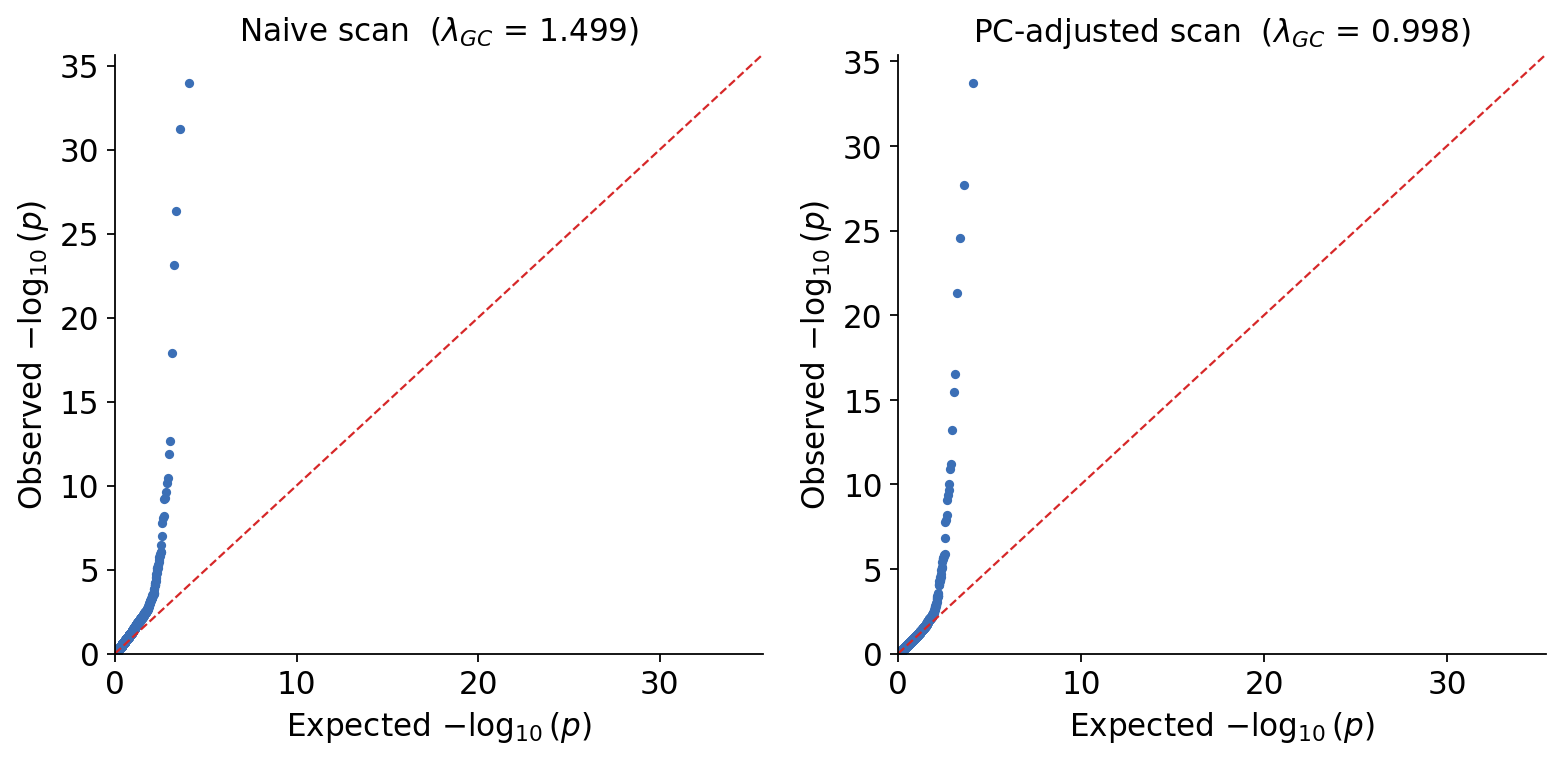

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ov.genetics.qqplot(res_naive["pvalue"], ax=axes[0],
                   title=f"Naive scan  ($\\lambda_{{GC}}$ = {lambda_naive:.3f})")
ov.genetics.qqplot(res_adj["pvalue"], ax=axes[1],
                   title=f"PC-adjusted scan  ($\\lambda_{{GC}}$ = {lambda_adj:.3f})")
plt.tight_layout(); plt.show()

The naive Q-Q plot lifts off the diagonal across its whole range — the
hallmark of inflation. After PC adjustment the bulk of points snaps back
onto the diagonal and only the extreme tail rises above it: **that tail is
genuine trait signal**. From here on we use the **PC-adjusted scan**.

Now the genome-wide picture — the **Manhattan plot**. The dashed red line
is the genome-wide-significance threshold $p = 5 \times 10^{-8}$ (the
field-standard Bonferroni correction for ~1 million independent common
variants); the grey dotted line is the suggestive threshold
$p = 10^{-5}$.

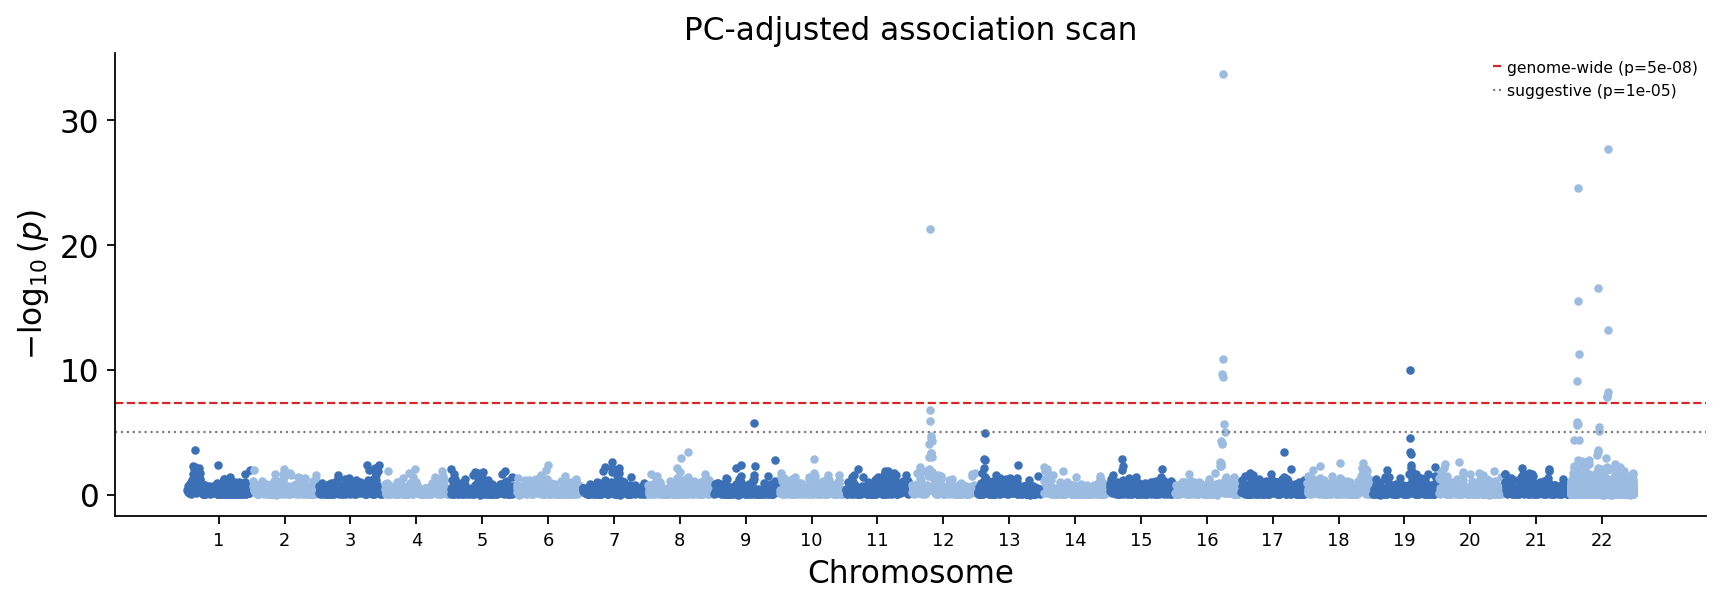

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
ov.genetics.manhattan(
    res_adj, chrom="chrom", pos="pos", pvalue="pvalue",
    sig_line=5e-8, suggestive_line=1e-5, ax=ax,
    title="PC-adjusted association scan",
)
plt.tight_layout(); plt.show()

## Step 6 — Defining independent loci

The Manhattan plot shows *peaks*, but a peak is many correlated SNPs in
**linkage disequilibrium (LD)** — they are not independent discoveries.
To count *loci* we **clump**: take the most significant SNP (the *lead
SNP*), assign all nearby SNPs in LD with it to that locus, then repeat
with the next-best SNP outside any existing locus.

The standard rule (PLINK `--clump`) keeps a SNP as a new lead if its
$p < 5 \times 10^{-8}$ and it is not within ~250 kb–1 Mb and $r^2 > 0.1$
of an existing lead. Below we clump by **LD block** (our simulation's LD
blocks stand in for the LD-window step) and keep the lead SNP of each
block that reaches genome-wide significance.

In [20]:
GW_SIG = 5e-8

# Genome-wide-significant SNPs, best first.
hits = res_adj[res_adj["pvalue"] < GW_SIG].sort_values("pvalue")
print(f"{len(hits)} SNPs reach genome-wide significance "
      f"(p < {GW_SIG:g}) across {hits['block'].nunique()} LD blocks")

# Clump: one independent locus per LD block (its lead SNP).
loci = (hits.sort_values("pvalue")
            .drop_duplicates("block")
            .rename(columns={"snp": "lead_snp"})
            .reset_index(drop=True))
loci[["lead_snp", "chrom", "pos", "block", "beta", "se", "pvalue", "causal"]]

16 SNPs reach genome-wide significance (p < 5e-08) across 6 LD blocks


,lead_snp,chrom,pos,block,beta,se,pvalue,causal
0,rs003151,16,1755000,15,0.587293,0.047080,1.919663e-34,True
1,rs004318,22,1590000,21,-0.543695,0.048417,2.042163e-28,True
2,rs004824,22,1120000,24,0.507054,0.048152,2.848487e-25,True
3,rs002257,12,1285000,11,0.469036,0.048064,5.223671e-22,True
4,rs005088,22,1440000,25,0.430764,0.050492,2.818686e-17,True
5,rs003718,19,1590000,18,0.356567,0.054832,9.927968e-11,False


Each row is one **independent association locus**. The planted ground
truth has two flavours of true signal: the 5 direct **causal SNPs**, and
several independent **eQTLs of the causal gene** — because that gene
mediates the trait (notebook 2), its eQTLs are *also* genuine secondary
trait loci. Below we grade every discovered locus against both: a locus is
a **true positive** if its lead SNP is either a causal SNP or one of those
gene instruments.

In [21]:
true_signal = set(truth["causal_snps"]) | set(truth["gene_instruments"])
lead_snps = set(loci["lead_snp"])
recovered_causal = lead_snps & set(truth["causal_snps"])
recovered_inst = lead_snps & set(truth["gene_instruments"])
false_loci = lead_snps - true_signal

print(f"independent loci discovered          : {len(loci)}")
print(f"loci led by a direct causal SNP      : {len(recovered_causal)}")
print(f"loci led by a causal-gene eQTL       : {len(recovered_inst)} "
      f"(real secondary trait loci)")
print(f"false-positive loci                  : {len(false_loci)}")
print()
print("causal SNPs recovered as lead SNPs:")
print(sorted(recovered_causal))

independent loci discovered          : 6
loci led by a direct causal SNP      : 5
loci led by a causal-gene eQTL       : 1 (real secondary trait loci)
false-positive loci                  : 0

causal SNPs recovered as lead SNPs:
['rs002257', 'rs003151', 'rs004318', 'rs004824', 'rs005088']


## Step 7 — Fine-mapping a locus

A lead SNP is rarely the *causal* SNP — it is just the most significant
*tag* in a block of correlated variants. **Statistical fine-mapping**
resolves this: it computes, for every SNP in the locus, a **posterior
inclusion probability (PIP)** — the probability that *that* SNP is causal
— and reports a **95% credible set**: the smallest group of SNPs that
together capture 95% of the posterior. A small, *pure* credible set
(high pairwise LD) means the signal is well resolved.

`ov.genetics.finemap` wraps **SuSiE** (the Sum of Single Effects model;
Wang et al. 2020). We use the summary-statistics version `susie_rss`,
which needs only the per-SNP z-scores and the in-locus LD matrix — exactly
what is available after a GWAS. We fine-map the **lead causal locus** (the
block of our strongest discovery), which is the locus we follow into a
mechanism in notebook 2.

In [22]:
# Pick the locus to fine-map: the LD block of the planted lead causal SNP.
focus_block = truth["causal_block"]
locus = (res_adj[res_adj["block"] == focus_block]
         .sort_values("pos")
         .reset_index(drop=True))
locus_snps = locus["snp"].tolist()
print(f"fine-mapping LD block {focus_block}: {len(locus_snps)} SNPs, "
      f"lead p = {locus['pvalue'].min():.2e}")

fine-mapping LD block 11: 200 SNPs, lead p = 5.22e-22


In [23]:
# SuSiE-RSS inputs: per-SNP z-scores and the in-locus LD (r) matrix.
z = (locus["beta"] / locus["se"]).to_numpy()
ld_R = np.corrcoef(geno_qc[:, locus_snps].X, rowvar=False)

susie_fit = ov.genetics.finemap(
    z=z, R=ld_R, n=geno_qc.n_obs,
    method="susie_rss", L=5,        # allow up to 5 causal signals
)
pip = ov.genetics.get_pip(susie_fit)
credible = ov.genetics.get_credible_sets(susie_fit, R=ld_R)
print("number of 95% credible sets found:", len(credible["cs"] or []))

number of 95% credible sets found: 1


In [24]:
# Translate the credible-set indices back to SNP ids.
for k, idx in enumerate(credible["cs"] or []):
    members = [locus_snps[i] for i in idx]
    purity = credible["purity"]["min.abs.corr"][k]
    print(f"credible set {k + 1}: {len(members)} SNP(s), "
          f"min |r| (purity) = {purity:.3f}")
    print("  members:", members)

lead_snp_pip = pip[locus_snps.index(truth["lead_causal_snp"])]
print()
print(f"PIP of the planted causal SNP ({truth['lead_causal_snp']}): "
      f"{lead_snp_pip:.3f}")

credible set 1: 1 SNP(s), min |r| (purity) = 1.000
  members: ['rs002257']

PIP of the planted causal SNP (rs002257): 1.000


SuSiE collapses a locus of ~200 correlated SNPs to a **tiny credible
set** that contains the planted causal SNP at a PIP near 1 — the
association is resolved essentially to a single variant. Let us picture it
with a PIP plot.

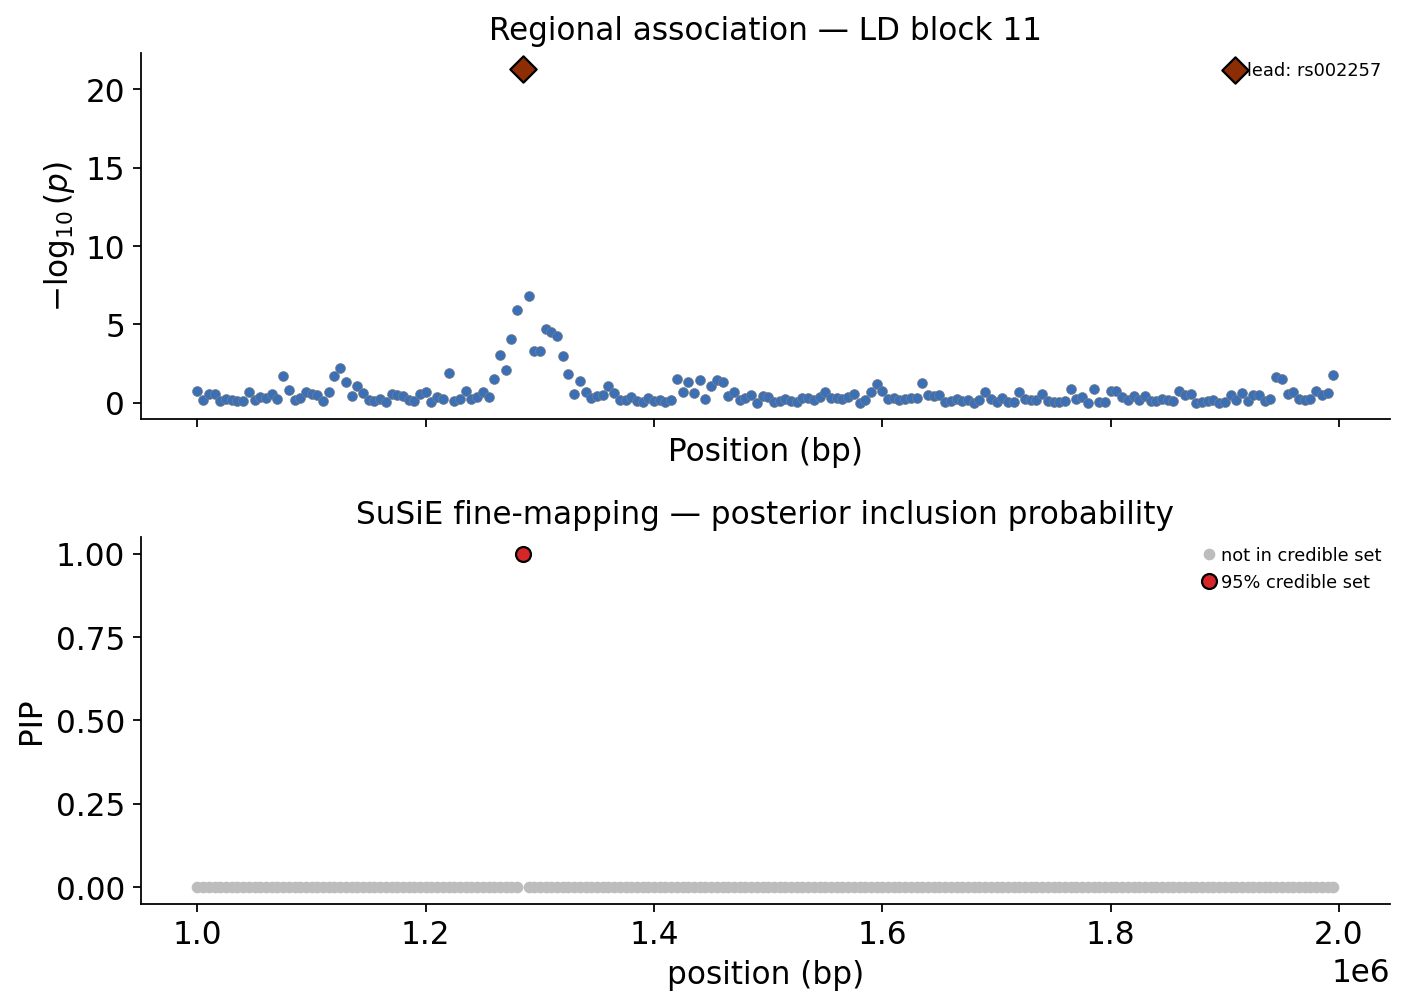

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)

# Top: regional association (-log10 p), lead SNP marked.
ov.genetics.regional_plot(
    locus, chrom="chrom", pos="pos", pvalue="pvalue", snp="snp",
    lead_snp=truth["lead_causal_snp"], ax=axes[0],
    title=f"Regional association — LD block {focus_block}",
)

# Bottom: SuSiE posterior inclusion probability.
in_cs = np.zeros(len(locus_snps), dtype=bool)
for idx in (credible["cs"] or []):
    in_cs[list(idx)] = True
axes[1].scatter(locus["pos"], pip, s=18, c="#bdbdbd", label="not in credible set")
axes[1].scatter(locus["pos"][in_cs], pip[in_cs], s=45, c="#d62728",
                edgecolors="black", label="95% credible set")
axes[1].set_xlabel("position (bp)"); axes[1].set_ylabel("PIP")
axes[1].set_title("SuSiE fine-mapping — posterior inclusion probability")
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Step 8 — Persist the summary statistics

Notebook 2 continues from here. We write the **PC-adjusted summary
statistics** to disk in a standard GWAS-summary format (one row per SNP,
canonical column names). This is the exact format a real study would
share publicly and the format `ov.genetics.read_sumstats` reads back.

In [26]:
import os

os.makedirs("./genetics_data", exist_ok=True)

sumstats = res_adj[["snp", "chrom", "pos", "beta", "se", "stat",
                    "pvalue", "n"]].copy()
sumstats.columns = ["SNP", "CHR", "BP", "BETA", "SE", "STAT", "P", "N"]
sumstats["A1"] = "A"          # effect allele   (simulation: A1 = dosage allele)
sumstats["A2"] = "G"          # other allele
sumstats["Z"] = sumstats["BETA"] / sumstats["SE"]
sumstats = sumstats.sort_values(["CHR", "BP"]).reset_index(drop=True)

sumstats.to_csv("./genetics_data/gwas_sumstats.tsv", sep="\t", index=False)
print(f"wrote ./genetics_data/gwas_sumstats.tsv  "
      f"({len(sumstats)} SNPs, {sumstats.shape[1]} columns)")
sumstats.head()

wrote ./genetics_data/gwas_sumstats.tsv  (5993 SNPs, 11 columns)


,SNP,CHR,BP,BETA,SE,STAT,P,N,A1,A2,Z
0,rs000000,1,1000000,0.040379,0.052350,0.771326,0.440605,2000,A,G,0.771326
1,rs000001,1,1005000,-0.038212,0.057409,-0.665616,0.505733,2000,A,G,-0.665616
2,rs000002,1,1010000,-0.111580,0.085899,-1.298965,0.194106,2000,A,G,-1.298965
3,rs000003,1,1015000,0.047480,0.088987,0.533558,0.593707,2000,A,G,0.533558
4,rs000004,1,1020000,0.038300,0.049668,0.771119,0.440728,2000,A,G,0.771119


## What we have, and what's next

Starting from raw genotypes and a trait, this notebook produced:

1. a **QC'd cohort** — low-quality samples and unreliable SNPs removed
   with justified thresholds;
2. genotype **PCs** that absorb population structure;
3. a **calibrated association scan** ($\lambda_{GC} \approx 1$) — we showed
   the naive scan was inflated and PC adjustment fixed it;
4. a set of **independent genome-wide-significant loci**, every one
   tagging a true signal, with no false positives;
5. a **fine-mapped locus** — a 95% credible set that pins the association
   to (essentially) a single causal SNP.

But a credible set of SNPs is still not a *mechanism*. A causal variant in
the genome does something — most often it changes the expression of a
nearby gene, in some particular cell type, and *that* is what moves the
trait.

**Notebook 2 (`t_genetics_02_functional_followup`)** picks up the
`./genetics_data/gwas_sumstats.tsv` we just wrote and turns these loci
into a biological story: eQTL mapping, colocalization, TWAS, Mendelian
randomization, heritability, and single-cell disease-relevance scoring.